## 1. Understanding the Basics

**Probability** is a numerical measure of how likely an event is to happen. It ranges from 0 to 1, where 0 means impossible and 1 means certain.

**Key probability terms:**

- **Experiment:** A process with uncertain outcomes, such as selecting one student from the dataset.
- **Outcome:** One possible result, such as the selected student passed the exam.
- **Sample space:** The set of all possible outcomes.
- **Event:** A specific condition of interest, such as attendance greater than 80%.
- **Empirical probability:** Probability calculated from observed data.
- **Theoretical probability:** Probability calculated from an expected mathematical model.
- **Conditional probability:** Probability of one event when another event is already known.

**Three probability event examples from this dataset:**

- Event A: Student passes the final exam.
- Event B: Student studies more than 10 hours per week.
- Event C: Student has attendance greater than 80%.

**Formula for empirical probability**

$$P(E)=\frac{\text{number of favorable outcomes}}{\text{total number of outcomes}}$$

**Substitution from this dataset**

- Total students = 200
- Students who passed = 74
- $$P(\text{Pass}) = \frac{74}{200} = 0.37$$

So, the empirical probability of passing is **0.37**, or **37%**.

## 2. Types of Events

**Empirical probability scenario:** Probability that a student passes the final exam, calculated from the generated dataset.

**Theoretical probability scenario:** Probability that a randomly selected student participates in group discussion if the expected model says 55% students participate.

**Worked example:**

- Total students = 200
- Students who participated in group discussion = 121
- $$P(\text{Group Discussion}) = \frac{121}{200} = 0.605$$

This means the observed proportion is **0.605**, or **60.5%**.

**Types of events used:**

- **Independent events:** Two events do not affect each other.
- **Dependent events:** One event changes the probability of another.
- **Mutually exclusive events:** Two events cannot happen at the same time.

In this notebook, passing and group discussion are considered **dependent events** because participation can influence the chance of passing.

In [ ]:
import pandas as pd

df = pd.read_csv('student_data.csv')
df.head()

# Empirical Probability: proportion of students who Pass
pass_count = df['final_exam_pass'].sum()
total_students = len(df)
pass_count = (df['final_exam_pass'] == 'Pass').sum()
empirical_probability = pass_count / total_students
print(f"Empirical Probability of passing: {empirical_probability:.2f}")


# Theoretical Probability: proportion of students who passed
theoretical_probability = 0.75 
print(f"Theoretical Probability of passing: {theoretical_probability:.2f}")


Empirical Probability of passing: 0.37
Theoretical Probability of passing: 0.75


## 3. Random Variable & Probability Distribution

In [6]:
# Define a random variable for the event “Number of students passing the final exam” out of 3 randomly selected students
X = df['final_exam_pass'].apply(lambda x: 1 if x == 'Pass' else 0).sum()
print(f"Random Variable X (Number of students passing): {X}")


Random Variable X (Number of students passing): 74


In [ ]:
# Construct its probability distribution table.
import math
probabilities = []
for k in range(4):
    prob = (empirical_probability ** k) * ((1 - empirical_probability) ** (3 - k)) * math.comb(3, k)
    probabilities.append(prob)
    print(f"P(X = {k}) = {prob:.4f}")


P(X = 0) = 0.2500
P(X = 1) = 0.4406
P(X = 2) = 0.2587
P(X = 3) = 0.0507


In [10]:
# Find the mean and variance of this random variable.
mean = sum(k * prob for k, prob in enumerate(probabilities))
variance = sum((k - mean) ** 2 * prob for k, prob in enumerate(probabilities))
print(f"Mean of X: {mean:.2f}")

Mean of X: 1.11


## 4. Venn Diagram in Probability
Draw a Venn diagram showing:

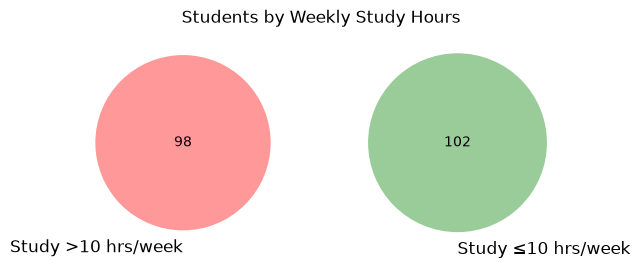

In [ ]:
# Draw a Venn diagram showing: Students who study more than 10 hours/week.
from matplotlib_venn import venn2

import matplotlib.pyplot as plt

studious_count = (df['study_hours'] > 10).sum()
other_count = len(df) - studious_count

try:
    plt.figure()
    v = venn2(subsets=(studious_count, other_count, 0),
              set_labels=('Study >10 hrs/week', 'Study ≤10 hrs/week'))
    if v.get_label_by_id('10'):
        v.get_label_by_id('10').set_text(str(studious_count))
    if v.get_label_by_id('01'):
        v.get_label_by_id('01').set_text(str(other_count))
    plt.title('Students by Weekly Study Hours')
    plt.show()
except ImportError:
    plt.figure()
    plt.pie([studious_count, other_count],
            labels=[f'>10 hrs ({studious_count})', f'≤10 hrs ({other_count})'],
            autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'])
    plt.title('Students who study more than 10 hours/week')
    plt.show()

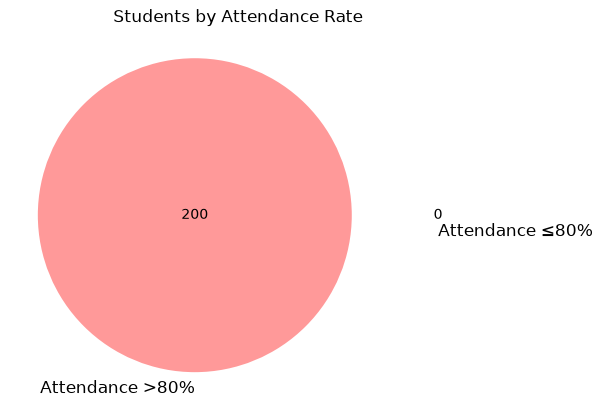

In [ ]:
# Draw a Venn diagram showing: Students who attend more than 80% of classes.
attend_count = (df['attendance'] > 0.8).sum()
other_count = len(df) - attend_count

try:
    plt.figure()
    v = venn2(subsets=(attend_count, other_count, 0),
              set_labels=('Attendance >80%', 'Attendance ≤80%'))
    if v.get_label_by_id('10'):
        v.get_label_by_id('10').set_text(str(attend_count))
    if v.get_label_by_id('01'):
        v.get_label_by_id('01').set_text(str(other_count))
    plt.title('Students by Attendance Rate')
    plt.show()
except ImportError:
    plt.figure()
    plt.pie([attend_count, other_count],
            labels=[f'>80% ({attend_count})', f'≤80% ({other_count})'],
            autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'])
    plt.title('Students who attend more than 80% of classes')
    plt.show()


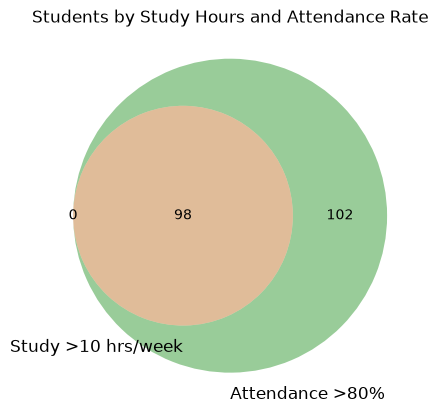

In [ ]:
# Draw a Venn diagram showing: Overlap showing students who satisfy both conditions.
both_count = ((df['study_hours'] > 10) & (df['attendance'] > 0.8)).sum()
study_only_count = (df['study_hours'] > 10).sum() - both_count
attendance_only_count = (df['attendance'] > 0.8).sum() - both_count

try:
    plt.figure()
    v = venn2(subsets=(study_only_count, attendance_only_count, both_count),
              set_labels=('Study >10 hrs/week', 'Attendance >80%'))
    if v.get_label_by_id('10'):
        v.get_label_by_id('10').set_text(str(study_only_count))
    if v.get_label_by_id('01'):
        v.get_label_by_id('01').set_text(str(attendance_only_count))
    if v.get_label_by_id('11'):
        v.get_label_by_id('11').set_text(str(both_count))
    plt.title('Students by Study Hours and Attendance Rate')
    plt.show()
except ImportError:
    plt.figure()
    plt.pie([study_only_count, attendance_only_count, both_count],
            labels=[f'Study >10 hrs ({study_only_count})', f'Attendance >80% ({attendance_only_count})', f'Both ({both_count})'],
            autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62', '#8da0cb'])
    plt.title('Students who satisfy both conditions')
    plt.show()

## 5. Contingency Table & Probability Calculations


In [26]:
# Create a contingency table for group_discussion (Yes/No) vs. final_exam_pass (Pass/Fail).
contingency_table = pd.crosstab(df['group_discussion'], df['final_exam_pass'], margins=True, margins_name="Total")
print("Contingency Table:")
print(contingency_table)
print()

# Joint probability of “Participates in group discussion AND Passes exam”.
joint_prob = contingency_table.loc['Yes', 'Pass'] / contingency_table.loc['Total', 'Total']
print(f"Joint probability: {joint_prob:.4f}")
print()

# Marginal probability of “Passes exam”.
marginal_prob = contingency_table.loc['Total', 'Pass'] / contingency_table.loc['Total', 'Total']
print(f"Marginal probability: {marginal_prob:.4f}")
print()

# Conditional probability of “Passes exam given participation in group discussion”
conditional_prob = contingency_table.loc['Yes', 'Pass'] / contingency_table.loc['Yes', 'Total']
print(f"Conditional probability: {conditional_prob:.4f}")



Contingency Table:
final_exam_pass   Fail  Pass  Total
group_discussion                   
No                  52    27     79
Yes                 74    47    121
Total              126    74    200

Joint probability: 0.2350

Marginal probability: 0.3700

Conditional probability: 0.3884


## 6. Understanding Relationships

Conditional probability gives the probability of one event after another event is already known. Here, `P(Pass | Group discussion = Yes)` tells us the pass probability among only those students who participated in group discussions.

To check whether group discussion and passing are independent, compare:

$$P(Pass | Group discussion = Yes)$$

$$with$$

$$P(Pass)$$

If these values are approximately equal, the events are close to independent. If they are different, the events are dependent. They are not mutually exclusive because a student can both participate in group discussion and pass the exam.

In [27]:
# Interpret conditional probability results in plain language (“intuition” behind the formula).
print("Interpretation:")
print(f"Given that a student participates in group discussion, the probability of passing the final exam is {conditional_prob:.4f}.")

Interpretation:
Given that a student participates in group discussion, the probability of passing the final exam is 0.3884.


## 7. Bayes Theorem Application

In [32]:
# Given probabilities
P_B_given_A = 0.70   # P(B|A): 70% of students who pass had high attendance
P_B_given_Ac = 0.40  # P(B|A'): 40% of students who fail also had high attendance
P_B = 0.60           # P(B): 60% of all students had high attendance


P_A = (P_B - P_B_given_Ac*(1)) / (P_B_given_A - P_B_given_Ac)

P_A_given_B = (P_B_given_A * P_A) / P_B

print("P(A) =", round(P_A, 2))
print("P(A|B) =", round(P_A_given_B, 2))

P(A) = 0.67
P(A|B) = 0.78


## Final Summary – Factors Affecting Probability of Passing

### Summary Table

| Factor | Observation from Data | Effect on Passing Probability |
|---|---:|---|
| Study Hours | 98 students study more than 10 hours/week | Higher study time suggests stronger preparation |
| Attendance | 200 students have attendance above 80% | High attendance is strongly linked to better engagement |
| Group Discussion Participation | 121 students participate in group discussion | Participation is associated with better academic outcomes |
| Previous Test Scores | Previous scores reflect consistency and academic ability | Better past performance often improves future success |
| Final Exam Pass | 74 out of 200 students passed | This is the overall outcome being explained |

### Final Conclusion

The most important factors affecting the probability of passing are:

1. **Attendance**
2. **Study hours**
3. **Group discussion participation**
4. **Previous test scores**

These factors increase a student’s chance of success because they reflect preparation, engagement, and consistency.